Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset folder: /content/drive/MyDrive/FER_Custom_Dataset
Subfolders: ['neutral', 'interested', 'Disappointed']
Sample image: /content/drive/MyDrive/FER_Custom_Dataset/neutral/next 5k5520.jpg
Detected brightness: 0.39
No adjustment needed.


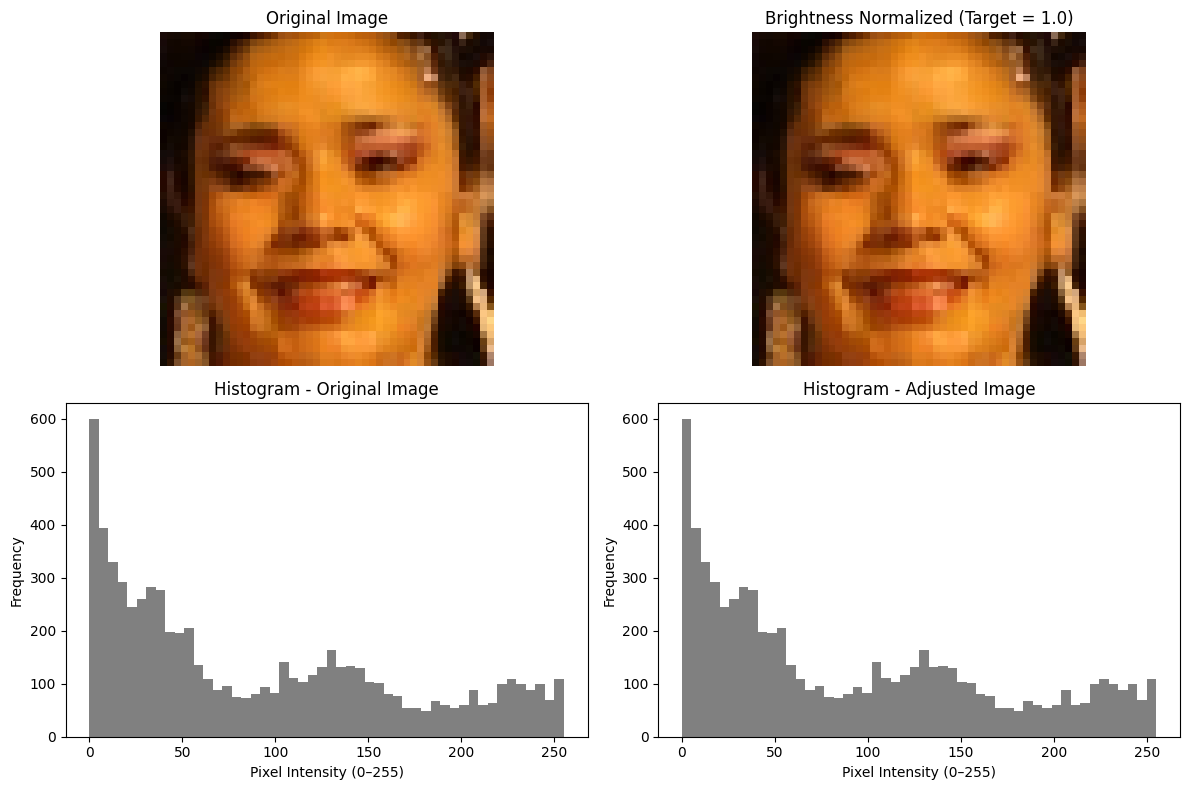

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


dataset_path = "/content/drive/MyDrive/FER_Custom_Dataset"

import os
print("Dataset folder:", dataset_path)
print("Subfolders:", os.listdir(dataset_path))

# Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np
import cv2


#  Function to check & adjust brightness
def adjust_brightness_to_one(img_array):
    """
    Adjust brightness if it's between 0.5–1.0 (dark) or 1.0–1.5 (bright).
    Keeps brightness normalized at 1.0.
    """
    # Convert to grayscale to estimate brightness
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    brightness = np.mean(gray) / 255.0   # normalize [0,1]

    print(f"Detected brightness: {brightness:.2f}")

    if 0.5 <= brightness < 1.0:
        # brighten (scale up to 1.0)
        factor = 1.0 / brightness
        adjusted = np.clip(img_array * factor, 0, 255).astype(np.uint8)
        print("Adjusted: Dark → Normalized to 1.0")
        return adjusted

    elif 1.0 < brightness <= 1.5:
        # dim down to 1.0
        factor = 1.0 / brightness
        adjusted = np.clip(img_array * factor, 0, 255).astype(np.uint8)
        print("Adjusted: Bright → Normalized to 1.0")
        return adjusted

    else:
        # already okay
        print("No adjustment needed.")
        return img_array


# Pick one sample image
sample_image_path = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_image_path = os.path.join(root, f)
            break
    if sample_image_path:
        break

print("Sample image:", sample_image_path)

# Load image
img = load_img(sample_image_path, target_size=(48, 48))  # resize for FER
img_array = img_to_array(img).astype("uint8")

# Adjust brightness automatically
adjusted_img = adjust_brightness_to_one(img_array)

#  Show Results Image and Histogram EDA
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Original image
axs[0, 0].imshow(img_array.astype("uint8"))
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

# Adjusted image
axs[0, 1].imshow(adjusted_img.astype("uint8"))
axs[0, 1].set_title("Brightness Normalized (Target = 1.0)")
axs[0, 1].axis("off")

# Histogram of original image
axs[1, 0].hist(img_array.ravel(), bins=50, color='gray')
axs[1, 0].set_title("Histogram - Original Image")
axs[1, 0].set_xlabel("Pixel Intensity (0–255)")
axs[1, 0].set_ylabel("Frequency")

# Histogram of adjusted image
axs[1, 1].hist(adjusted_img.ravel(), bins=50, color='gray')
axs[1, 1].set_title("Histogram - Adjusted Image")
axs[1, 1].set_xlabel("Pixel Intensity (0–255)")
axs[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
